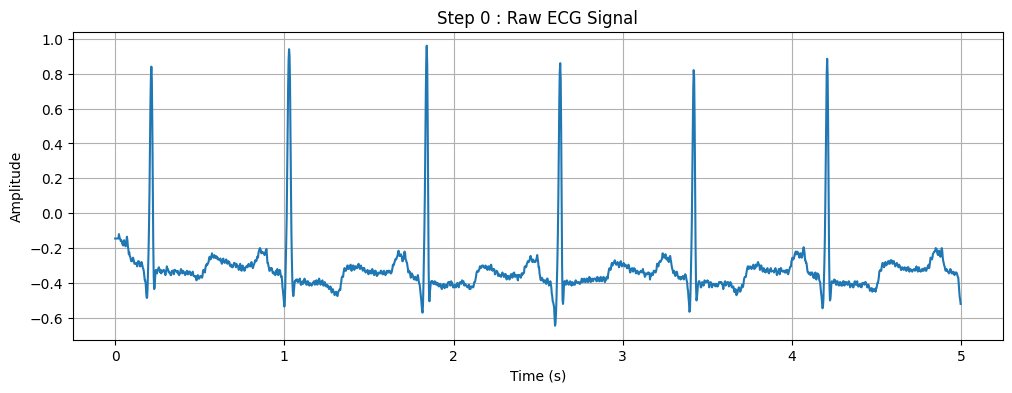

In [1]:
import wfdb
import pywt
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)

# ============================================
# STEP 0 : Load ECG
# ============================================

record_name = "100"
fs = 360
seconds = 5

total_samples = fs * seconds

print(f"Downloading MIT-BIH Record {record_name}...")

record = wfdb.rdsamp(
    record_name,
    pn_dir="mitdb",
    sampto=total_samples
)

ecg = record[0][:, 0]
t = np.arange(len(ecg)) / fs

plt.figure()
plt.plot(t, ecg)
plt.title("Step 0 : Raw ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


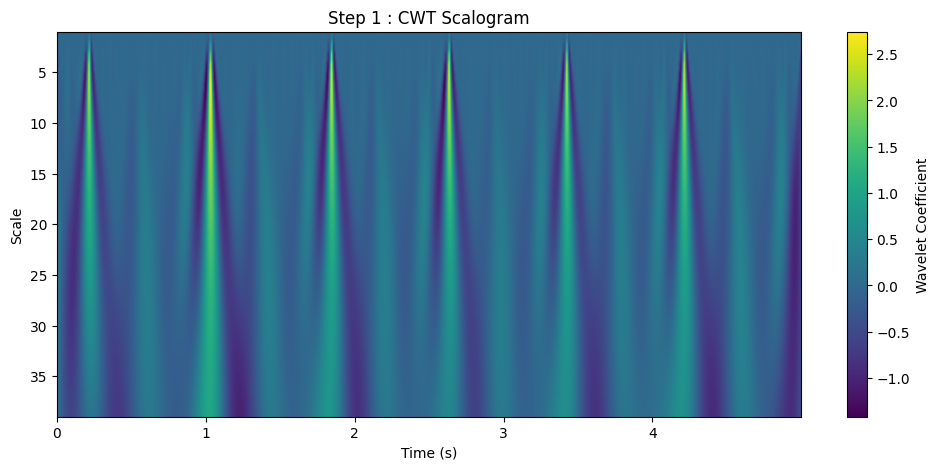

In [2]:
scales = np.arange(1, 40)

cwt_matrix, frequencies = pywt.cwt(
    ecg,
    scales,
    'mexh'
)

plt.figure(figsize=(12, 5))

plt.imshow(
    cwt_matrix,
    extent=[t[0], t[-1], scales[-1], scales[0]],
    cmap='viridis',
    aspect='auto'
)

plt.colorbar(label="Wavelet Coefficient")
plt.title("Step 1 : CWT Scalogram")
plt.xlabel("Time (s)")
plt.ylabel("Scale")
plt.show()


Selected Scale = 15


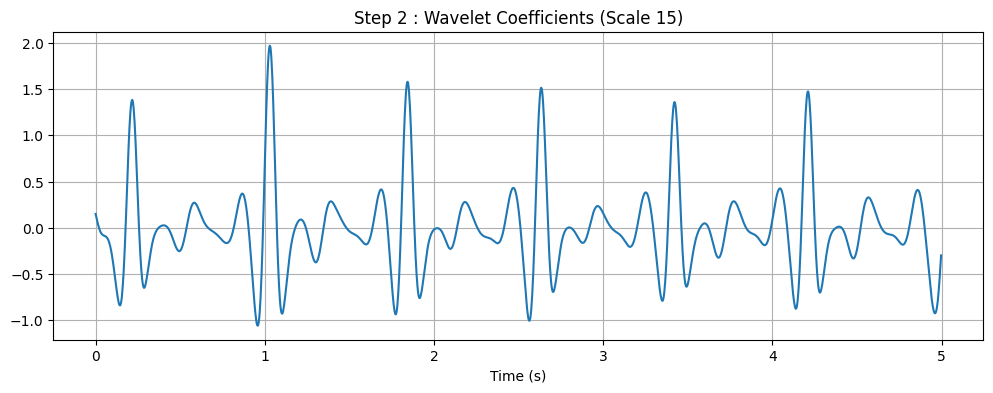

In [3]:
# ============================================
# STEP 2 : Choose Best Scale
# ============================================

scale_variance = np.var(cwt_matrix, axis=1)

best_scale_idx = np.argmax(scale_variance)
best_scale = scales[best_scale_idx]

coeffs = cwt_matrix[best_scale_idx]

print(f"Selected Scale = {best_scale}")

plt.figure()
plt.plot(t, coeffs)
plt.title(f"Step 2 : Wavelet Coefficients (Scale {best_scale})")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()


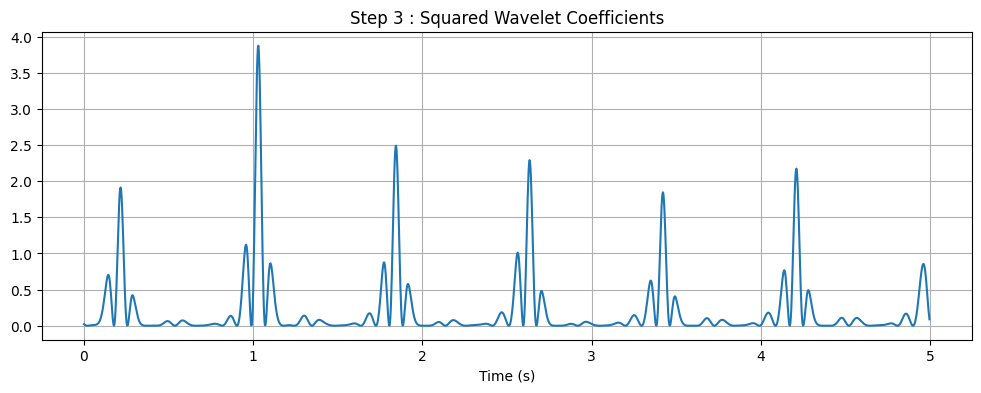

In [4]:
# ============================================
# STEP 3 : Energy Enhancement
# ============================================

energy = coeffs ** 2

plt.figure()
plt.plot(t, energy)
plt.title("Step 3 : Squared Wavelet Coefficients")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()


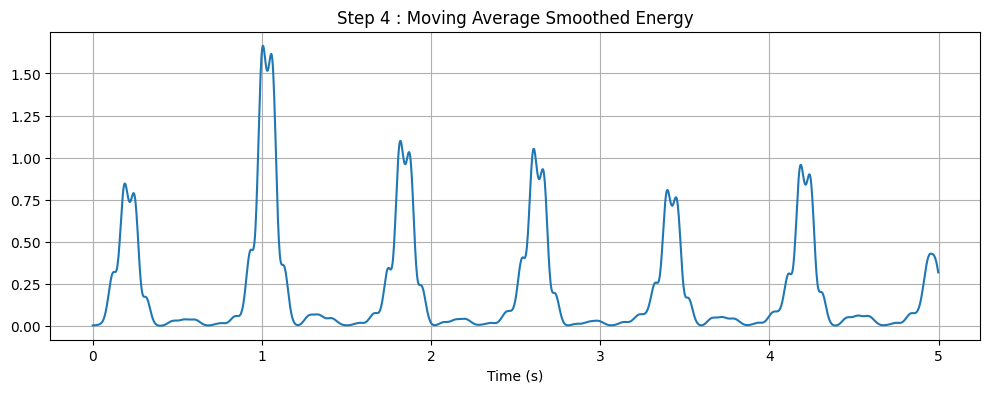

In [5]:
# ============================================
# STEP 4 : Smoothing
# ============================================

window_size = int(0.10 * fs)

smoothed = np.convolve(
    energy,
    np.ones(window_size) / window_size,
    mode='same'
)

plt.figure()
plt.plot(t, smoothed)
plt.title("Step 4 : Moving Average Smoothed Energy")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()


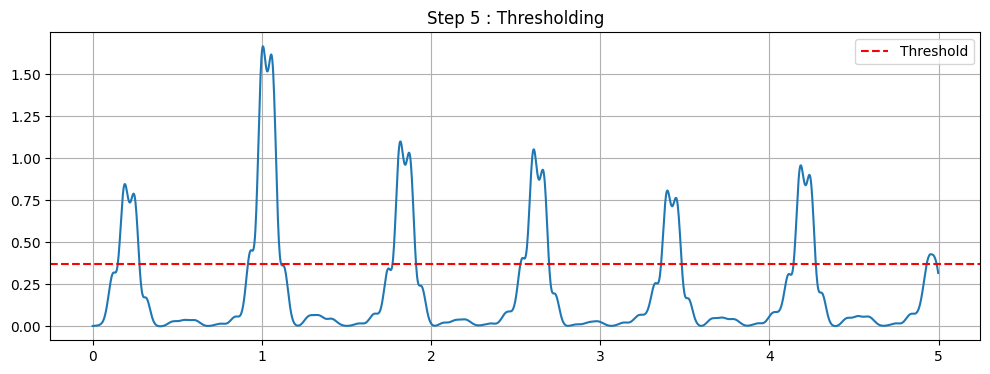

In [7]:
# ============================================
# STEP 5 : Adaptive Threshold
# ============================================

threshold = np.mean(smoothed) + 0.5 * np.std(smoothed)

plt.figure()
plt.plot(t, smoothed)
plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)
plt.title("Step 5 : Thresholding")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# ============================================
# STEP 6 : Peak Detection
# ============================================

min_distance = int(0.25 * fs)

candidate_peaks, _ = signal.find_peaks(
    smoothed,
    height=threshold,
    distance=min_distance
)


In [9]:
# ============================================
# STEP 7 : Refine Peak Location
# Search nearby maximum in original ECG
# ============================================

search_radius = int(0.08 * fs)

r_peaks = []

for p in candidate_peaks:

    start = max(0, p - search_radius)
    end = min(len(ecg), p + search_radius)

    local_max = np.argmax(ecg[start:end])

    r_peaks.append(start + local_max)

r_peaks = np.array(sorted(set(r_peaks)))

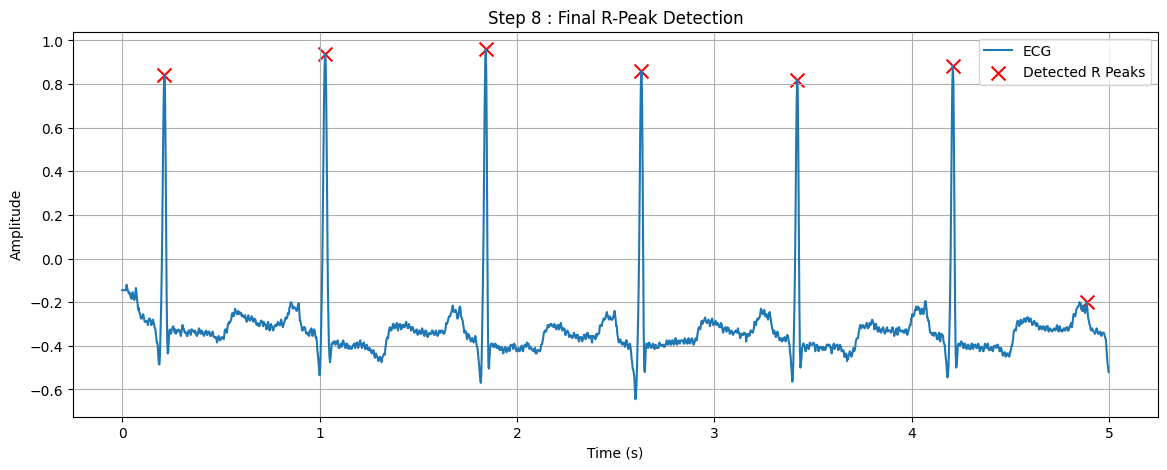


Detected R-peaks : 7
Estimated Heart Rate : 84.0 BPM


In [10]:
# ============================================
# STEP 8 : Final Detection
# ============================================

plt.figure(figsize=(14, 5))

plt.plot(t, ecg, label="ECG")

plt.scatter(
    t[r_peaks],
    ecg[r_peaks],
    color='red',
    marker='x',
    s=100,
    label='Detected R Peaks'
)

plt.title("Step 8 : Final R-Peak Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# Statistics
# ============================================

heart_rate = len(r_peaks) * 60 / seconds

print(f"\nDetected R-peaks : {len(r_peaks)}")
print(f"Estimated Heart Rate : {heart_rate:.1f} BPM")